# 03 — Model Training & Run History

**流程**: 加载数据 → 时序划分 → 特征选择(仅训练集) → 全模型超参调优 → 测试集评估 → 收敛性检查 → 保存运行记录

**核心功能**:
1. ✅ 特征选择仅在训练集上进行，避免数据泄露
2. ✅ 全部模型调优后，按 Test RMSE 排序评估
3. ✅ 每次运行结果追加到 `outputs/run_history.csv`，重跑时可对比哪次 RMSE 最低
4. ✅ 历史集成流程已拆分到 `notebooks/04_ensemble.ipynb`

**输入**: `data/raw/train_data.csv`  
**输出**: `outputs/models/*.pkl`, `outputs/run_history.csv`, `outputs/figures/*.png`

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import json
import pandas as pd
import numpy as np
from datetime import datetime

from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from config import DATA_RAW, TARGET, MODEL_DIR, FIG_DIR, RANDOM_STATE
from src.preprocessing import load_and_clean, build_feature_matrix
from src.feature_engineering import compute_ensemble_importance
from src.models import discover_models, save_model

RUN_HISTORY_PATH = MODEL_DIR.parent / "run_history.csv"
TOP_K = 3

# ── 每次运行前可修改此备注，记录本次改了什么 ──
RUN_NOTES = ""

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. 加载原始数据 & 时序划分

从原始数据重新开始，按时间排序后按 80/20 划分训练集和测试集。  
使用**时序划分**（前 80% 训练、后 20% 测试），确保不会用"未来数据"训练。

In [2]:
df = load_and_clean(DATA_RAW)
df = df.sort_values('startdate').reset_index(drop=True)

X_full, y_full, all_features = build_feature_matrix(df, TARGET)
print(f"Full dataset: X={X_full.shape}, y={y_full.shape}")
print(f"Total features (before selection): {len(all_features)}")

split_idx = int(len(X_full) * 0.8)
X_train_raw, X_test_raw = X_full.iloc[:split_idx], X_full.iloc[split_idx:]
y_train, y_test = y_full.iloc[:split_idx], y_full.iloc[split_idx:]

print(f"\nTrain: {X_train_raw.shape}  (rows 0–{split_idx - 1})")
print(f"Test:  {X_test_raw.shape}  (rows {split_idx}–{len(X_full) - 1})")

Full dataset: X=(375734, 242), y=(375734,)
Total features (before selection): 242

Train: (300587, 242)  (rows 0–300586)
Test:  (75147, 242)  (rows 300587–375733)


## 2. 特征选择（仅在训练集上）

使用 Lasso + ElasticNet + RandomForest 集成方法，**仅在训练集上**计算特征重要性。  
测试集完全不参与特征选择，杜绝数据泄露。

In [3]:
selected_score, full_score = compute_ensemble_importance(
    X_train_raw, y_train, top_n=30, use_cache=False
)
selected_features = selected_score.index.tolist()

print(f"\nSelected {len(selected_features)} features (train-only):")
print(selected_features)

X_train = X_train_raw[selected_features]
X_test = X_test_raw[selected_features]
print(f"\nX_train: {X_train.shape}, X_test: {X_test.shape}")

  [1/3] Lasso …
  [2/3] ElasticNet …
  [3/3] RandomForest …
  Top-30 投票 ≥2/3: 25 个特征 (3/3=5, 2/3=20)
  Cached scores to /Users/zhangjiayu/PythonProject/weather-forecast/outputs/cache/

Selected 25 features (train-only):
['contest-slp-14d__slp', 'contest-wind-h500-14d__wind-hgt-500', 'nmme-tmp2m-34w__gfdlflorb', 'nmme-tmp2m-34w__cfsv2', 'nmme-tmp2m-56w__cfsv2', 'nmme-tmp2m-56w__gfdlflorb', 'contest-wind-h850-14d__wind-hgt-850', 'nmme-tmp2m-56w__nasa', 'nmme-tmp2m-56w__gfdlflora', 'nmme-tmp2m-34w__nasa', 'elevation__elevation', 'nmme-tmp2m-34w__gfdlflora', 'contest-wind-h100-14d__wind-hgt-100', 'lon', 'contest-pres-sfc-gauss-14d__pres', 'contest-rhum-sig995-14d__rhum', 'contest-wind-vwnd-925-14d__wind-vwnd-925', 'wind-vwnd-925-2010-8', 'wind-hgt-10-2010-9', 'contest-wind-uwnd-925-14d__wind-uwnd-925', 'icec-2010-8', 'wind-hgt-10-2010-7', 'sst-2010-5', 'wind-uwnd-250-2010-10', 'wind-uwnd-250-2010-18']

X_train: (300587, 25), X_test: (75147, 25)


In [4]:
import warnings
warnings.filterwarnings('ignore', message='X does not have valid feature names')

## 3. 超参数调优（所有模型）

使用 `TimeSeriesSplit(5折)` 交叉验证，用训练集最近 20% 的数据做调参（时序上最接近测试集，更有代表性）。  
**搜索策略**：根据搜索空间大小自动选择 — 组合数 ≤ `N_ITER` 时使用 `GridSearchCV` 穷举，否则使用 `RandomizedSearchCV` 随机搜索。  
**早停**：Boosting 模型（XGBoost / LightGBM / CatBoost）额外持有 20% 调参数据作为 eval set，patience=50 轮无提升即停止，避免跑满所有 iterations。

In [ ]:
import time as _time
import numpy as np
from functools import reduce
from operator import mul
from sklearn.preprocessing import StandardScaler as _SS
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit

_run_start = _time.time()

# 假设 discover_models() 和 X_train, y_train, RANDOM_STATE 已经在外部定义
registry = discover_models()
print(f"Discovered {len(registry)} models: {list(registry.keys())}")

TUNE_FRAC = 0.2
N_ITER = 20
BOOSTING_MODELS = {'xgboost', 'lightgbm', 'catboost'}
ES_ROUNDS = 50

# 1. 切分出调优集 (取时间序列的最后部分)
tune_size = int(len(X_train) * TUNE_FRAC)
X_tune = X_train.iloc[-tune_size:]
y_tune = y_train.iloc[-tune_size:]
print(f"Tuning subset: {X_tune.shape} (last {TUNE_FRAC:.0%} of train)")

# 2. 为 Boosting 模型的早停 (Early Stopping) 准备验证集
es_cut = int(len(X_tune) * 0.8)
X_tune_cv = X_tune.iloc[:es_cut]
y_tune_cv = y_tune.iloc[:es_cut]
X_tune_es = X_tune.iloc[es_cut:]
y_tune_es = y_tune.iloc[es_cut:]

# 去掉 .set_output(transform="pandas")，让 _es_scaler 输出最原始的 numpy 数组
_es_scaler = _SS().fit(X_tune_cv)
# 此时 X_es_scaled 已经是一个纯数字的 numpy 多维数组，不再是 DataFrame 了
X_es_scaled = _es_scaler.transform(X_tune_es)
print(f"  Boosting early-stop: CV on {len(X_tune_cv)} rows, "
      f"eval on {len(X_tune_es)} rows (patience={ES_ROUNDS})\n")

tscv_tune = TimeSeriesSplit(n_splits=5)
tuned_pipelines = {}
tuning_info = {}

for name, entry in registry.items():
    grid = entry.param_grid()
    
    if not grid:
        print(f"[{name}] No param_grid, keeping default.\n")
        tuned_pipelines[name] = entry.build_pipeline()
        tuning_info[name] = {"cv_rmse": None, "best_params": {}}
        continue

    # 计算参数组合总数，决定使用 GridSearch 还是 RandomizedSearch
    n_combos = reduce(mul, (len(v) for v in grid.values()), 1)
    use_grid = n_combos <= N_ITER

    if use_grid:
        print(f"[{name}] GridSearchCV ({n_combos} combos, 5-fold)...")
        search = GridSearchCV(
            entry.build_pipeline(), grid,
            cv=tscv_tune,
            scoring='neg_mean_squared_error',
            n_jobs=-1, verbose=0,
        )
    else:
        print(f"[{name}] RandomizedSearchCV ({n_combos} combos, n_iter={N_ITER}, 5-fold)...")
        search = RandomizedSearchCV(
            entry.build_pipeline(), grid,
            n_iter=N_ITER, cv=tscv_tune,
            scoring='neg_mean_squared_error',
            n_jobs=-1, random_state=RANDOM_STATE, verbose=0,
        )

    # 3. 针对不同模型执行拟合逻辑
    if name in BOOSTING_MODELS:
        # 为 Pipeline 中的模型步骤传递早停参数
        fit_params = {
            # X_es_scaled 已经是 numpy，y_tune_es 加上 .values 转成 numpy
            'model__eval_set': [(X_es_scaled, y_tune_es.values)],
        }
        
        if name == 'xgboost':
            fit_params['model__verbose'] = False
            search.estimator.set_params(model__early_stopping_rounds=ES_ROUNDS)
        elif name == 'lightgbm':
            import lightgbm as _lgb
            fit_params['model__callbacks'] = [
                _lgb.early_stopping(ES_ROUNDS, verbose=False),
                _lgb.log_evaluation(-1),
            ]
        elif name == 'catboost':
            # 补齐 CatBoost 的早停参数
            fit_params['model__early_stopping_rounds'] = ES_ROUNDS
            fit_params['model__verbose'] = False

        search.fit(X_tune_cv.values, y_tune_cv.values, **fit_params)
    else:
        # 非 Boosting 模型使用 100% 调优集时，同样加上 .values
        search.fit(X_tune.values, y_tune.values)

    # 4. 记录结果
    cv_rmse = np.sqrt(-search.best_score_)
    print(f"  CV RMSE: {cv_rmse:.4f}")
    print(f"  Params:  {search.best_params_}\n")
    
    tuned_pipelines[name] = search.best_estimator_
    tuning_info[name] = {
        "cv_rmse": round(cv_rmse, 4),
        "best_params": search.best_params_,
    }

print(f"Done. Tuned {len(tuned_pipelines)} models. Time elapsed: {_time.time() - _run_start:.2f}s")

Discovered 6 models: ['catboost', 'elasticnet', 'lasso', 'lightgbm', 'random_forest', 'xgboost']
Tuning subset: (60117, 25) (last 20% of train)
  Boosting early-stop: CV on 48093 rows, eval on 12024 rows (patience=50)

[catboost] RandomizedSearchCV (120 combos, n_iter=20, 5-fold)...
  CV RMSE: 2.2226
  Params:  {'model__learning_rate': 0.03, 'model__l2_leaf_reg': 7, 'model__depth': 4, 'model__bagging_temperature': 1}

[elasticnet] GridSearchCV (20 combos, 5-fold)...
  CV RMSE: 1.9122
  Params:  {'model__alpha': 0.01, 'model__l1_ratio': 0.8}

[lasso] GridSearchCV (5 combos, 5-fold)...
  CV RMSE: 1.8875
  Params:  {'model__alpha': 0.01}

[lightgbm] RandomizedSearchCV (36 combos, n_iter=20, 5-fold)...


/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  CV RMSE: 2.1917
  Params:  {'model__num_leaves': 23, 'model__n_estimators': 300, 'model__learning_rate': 0.1}

[random_forest] RandomizedSearchCV (60 combos, n_iter=20, 5-fold)...


/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-pac

  CV RMSE: 2.4838
  Params:  {'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_depth': 20}

[xgboost] RandomizedSearchCV (36 combos, n_iter=20, 5-fold)...


/Users/zhangjiayu/miniforge3/envs/weather/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


  CV RMSE: 2.2366
  Params:  {'model__n_estimators': 500, 'model__max_depth': 6, 'model__learning_rate': 0.05}

Done. Tuned 6 models. Time elapsed: 711.53s


## 4. 测试集评估 → 选出 Top 3

用调参后的最优参数在**全量训练集**上训练，然后在 **20% 测试集**上评估。  
按 Test RMSE 排序，自动选出表现最好的 **Top 3** 模型。

In [8]:
test_rows = []
predictions = {}

for name, pipe in tuned_pipelines.items():
    
    if name == 'xgboost':
        pipe.set_params(model__early_stopping_rounds=None)

    pipe.fit(X_train.values, y_train.values)
    y_pred = pipe.predict(X_test.values)
    
    rmse = np.sqrt(mean_squared_error(y_test.values, y_pred))
    r2 = r2_score(y_test.values, y_pred)
    
    test_rows.append({
        'Model': name,
        'Test RMSE': round(rmse, 4),
        'Test R²': round(r2, 4),
    })
    predictions[name] = y_pred
    print(f"[{name}] RMSE={rmse:.4f}, R²={r2:.4f}")

all_results = pd.DataFrame(test_rows).set_index('Model').sort_values('Test RMSE')

top3_names = all_results.head(TOP_K).index.tolist()
print(f"\n{'='*55}")
print(f"  ★ Top {TOP_K} models: {top3_names}")
print(f"{'='*55}")
all_results

[catboost] RMSE=1.7674, R²=0.9227
[elasticnet] RMSE=1.8873, R²=0.9118
[lasso] RMSE=1.8935, R²=0.9113
[lightgbm] RMSE=1.6842, R²=0.9298
[random_forest] RMSE=1.9363, R²=0.9072
[xgboost] RMSE=2.0187, R²=0.8991

  ★ Top 3 models: ['lightgbm', 'catboost', 'elasticnet']


,Test RMSE,Test R²
Model,,
lightgbm,1.6842,0.9298
catboost,1.7674,0.9227
elasticnet,1.8873,0.9118
lasso,1.8935,0.9113
random_forest,1.9363,0.9072
xgboost,2.0187,0.8991


## 5. 收敛性检查

对**所有梯度提升模型**（CatBoost / XGBoost / LightGBM），用验证集重新训练并画 **训练 vs 验证 RMSE 曲线**。  
- 曲线末端趋于平坦 → 已收敛  
- 曲线末端仍在明显下降 → 可尝试增大 `iterations` / `n_estimators`  
- 验证曲线反而上升 → 过拟合，需降低复杂度

线性模型（Lasso / ElasticNet）和 RandomForest 不需要这种检查。

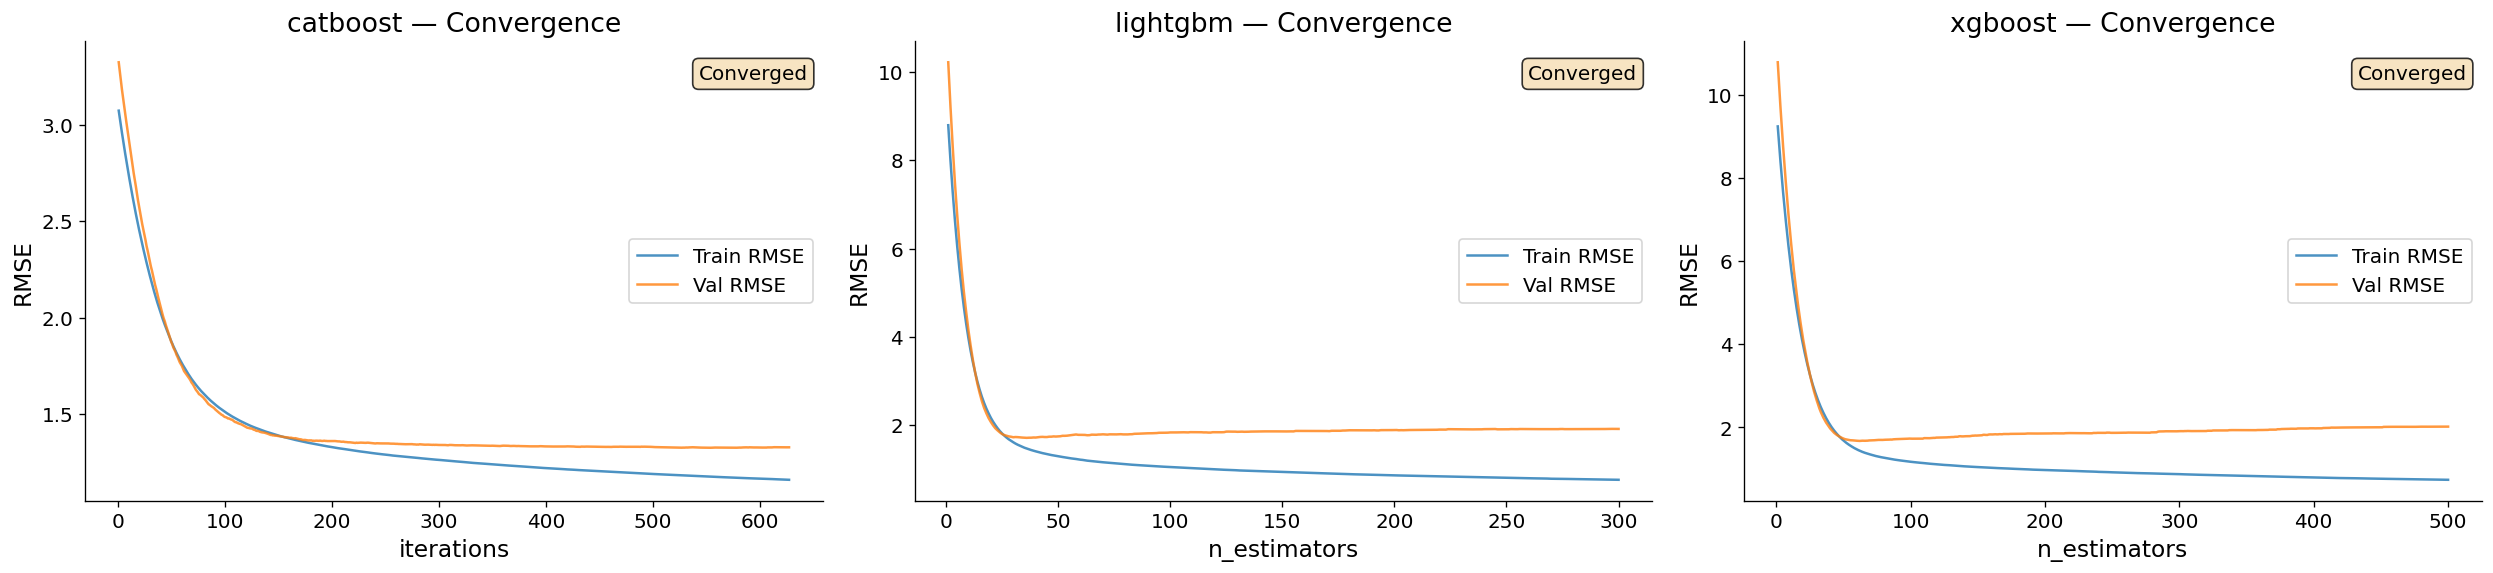

Saved → /Users/zhangjiayu/PythonProject/weather-forecast/outputs/figures/convergence_check.png


In [9]:
from sklearn.preprocessing import StandardScaler

boosting_models = {
    'catboost':  'iterations',
    'xgboost':   'n_estimators',
    'lightgbm':  'n_estimators',
}

all_boosting = [n for n in tuned_pipelines if n in boosting_models]

if not all_boosting:
    print("没有梯度提升模型，跳过收敛检查。")
else:
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_train)
    X_te_sc = scaler.transform(X_test)

    fig, axes = plt.subplots(1, len(all_boosting),
                             figsize=(7 * len(all_boosting), 5))
    if len(all_boosting) == 1:
        axes = [axes]

    for ax, name in zip(axes, all_boosting):
        pipe = tuned_pipelines[name]
        best_params = tuning_info[name]['best_params']
        inner_model = pipe.named_steps['model']
        params = inner_model.get_params()

        if name == 'catboost':
            from catboost import CatBoostRegressor
            cb_params = {k.replace('model__', ''): v for k, v in best_params.items()
                         if k.startswith('model__')}
            n_rounds = cb_params.pop('iterations', params.get('iterations', 500))
            model = CatBoostRegressor(
                **cb_params,
                iterations=n_rounds, verbose=0, random_seed=42,
                eval_metric='RMSE',
            )
            # use remaining params from tuned model
            model.set_params(**{k: v for k, v in params.items()
                                if k not in ('iterations', 'verbose', 'random_seed',
                                             'eval_metric')
                                and not k.startswith('_')})
            model.fit(X_tr_sc, y_train,
                      eval_set=(X_te_sc, y_test), verbose=0)
            train_rmse = [x ** 0.5 if x > 0 else x
                          for x in model.evals_result_['learn']['RMSE']]
            val_rmse = [x ** 0.5 if x > 0 else x
                        for x in model.evals_result_['validation']['RMSE']]

        elif name == 'xgboost':
            from xgboost import XGBRegressor
            n_rounds = params.get('n_estimators', 500)
            model = XGBRegressor(
                n_estimators=n_rounds,
                max_depth=params.get('max_depth', 6),
                learning_rate=params.get('learning_rate', 0.1),
                n_jobs=-1, random_state=42, verbosity=0,
                eval_metric='rmse',
            )
            model.fit(X_tr_sc, y_train,
                      eval_set=[(X_tr_sc, y_train), (X_te_sc, y_test)],
                      verbose=False)
            res = model.evals_result()
            train_rmse = res['validation_0']['rmse']
            val_rmse = res['validation_1']['rmse']

        elif name == 'lightgbm':
            from lightgbm import LGBMRegressor
            n_rounds = params.get('n_estimators', 500)
            model = LGBMRegressor(
                n_estimators=n_rounds,
                max_depth=params.get('max_depth', 6),
                learning_rate=params.get('learning_rate', 0.1),
                n_jobs=-1, random_state=42, verbose=-1,
            )
            model.fit(X_tr_sc, y_train,
                      eval_set=[(X_tr_sc, y_train), (X_te_sc, y_test)],
                      eval_names=['train', 'valid'],
                      eval_metric='rmse')
            train_rmse = model.evals_result_['train']['rmse']
            val_rmse = model.evals_result_['valid']['rmse']

        iters = range(1, len(train_rmse) + 1)
        ax.plot(iters, train_rmse, label='Train RMSE', linewidth=1.5, alpha=0.8)
        ax.plot(iters, val_rmse, label='Val RMSE', linewidth=1.5, alpha=0.8)
        ax.set_xlabel(boosting_models[name])
        ax.set_ylabel('RMSE')
        ax.set_title(f'{name} — Convergence')
        ax.legend()

        last_5_val = val_rmse[-5:]
        delta = last_5_val[0] - last_5_val[-1]
        if delta < 0.001:
            verdict = "Converged"
        elif delta < 0.01:
            verdict = "Near converged"
        else:
            verdict = "Not converged"
        ax.text(0.98, 0.95, verdict, transform=ax.transAxes,
                ha='right', va='top', fontsize=12,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'convergence_check.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {FIG_DIR / 'convergence_check.png'}")

## 6. 保存模型 & 运行记录

- Top 3 模型保存到 `outputs/models/<run_id>/` 子目录，**不会覆盖**历史运行
- 本次运行的**所有模型**结果追加到 `outputs/run_history.csv`
- 恢复某次历史模型: `load_model("catboost", run_id="20260310_231542")`

In [11]:
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
run_ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# ── 保存 Top 3 模型到 run_id 子目录 ──
for name in top3_names:
    save_model(tuned_pipelines[name], name, run_id=run_id)
print(f"Saved top 3 models → {MODEL_DIR / run_id}/")

run_dir = MODEL_DIR / run_id
features_path = run_dir / "selected_features.json"
with open(features_path, 'w') as f:
    json.dump(selected_features, f, indent=2)
print(f"Saved features → {features_path}")

# ── 构建运行记录 ──
history_rows = []
for name in all_results.index:
    info = tuning_info.get(name, {})
    history_rows.append({
        'run_id': run_id,
        'timestamp': run_ts,
        'model': name,
        'best_params': json.dumps(info.get('best_params', {})),
        'cv_rmse': info.get('cv_rmse', None),
        'test_rmse': all_results.loc[name, 'Test RMSE'],
        'test_r2': all_results.loc[name, 'Test R²'],
        'n_features': len(selected_features),
        'is_top3': name in top3_names,
        'notes': RUN_NOTES,
    })

new_rows = pd.DataFrame(history_rows)
if RUN_HISTORY_PATH.exists():
    history = pd.concat([pd.read_csv(RUN_HISTORY_PATH), new_rows], ignore_index=True)
else:
    history = new_rows
history.to_csv(RUN_HISTORY_PATH, index=False)

print(f"\n{'='*55}")
print(f"  Run [{run_id}] saved to {RUN_HISTORY_PATH}")
print(f"  Total runs in history: {history['run_id'].nunique()}")
print(f"{'='*55}")

Saved top 3 models → /Users/zhangjiayu/PythonProject/weather-forecast/outputs/models/20260322_121844/
Saved features → /Users/zhangjiayu/PythonProject/weather-forecast/outputs/models/20260322_121844/selected_features.json

  Run [20260322_121844] saved to /Users/zhangjiayu/PythonProject/weather-forecast/outputs/run_history.csv
  Total runs in history: 9


## 7. 历史运行对比

加载所有历史运行记录，表格展示每次 run 的最佳模型，多次运行时还会画 RMSE 变化趋势图。  
**使用方式**: 修改参数后重跑整个 notebook，这里会自动对比所有历史结果。

Total runs in history: 9

Best model per run (sorted by Test RMSE):


,run_id,timestamp,model,cv_rmse,test_rmse,test_r2,n_features,notes
0,20260322_121842,2026-03-22 12:18:42,lightgbm,2.1917,1.6842,0.9298,25,NaN
1,20260322_121844,2026-03-22 12:18:44,lightgbm,2.1917,1.6842,0.9298,25,NaN
2,20260311_004518,2026-03-11 00:45:18,elasticnet,1.9883,1.8873,0.9118,25,NaN
3,20260311_011610,2026-03-11 01:16:10,elasticnet,1.9883,1.8873,0.9118,25,NaN
4,20260311_072118,2026-03-11 07:21:18,elasticnet,1.9883,1.8873,0.9118,25,NaN
5,20260319_121319,2026-03-19 12:13:19,elasticnet,1.9883,1.8873,0.9118,25,NaN
6,20260319_132032,2026-03-19 13:20:32,elasticnet,1.9122,1.8873,0.9118,25,NaN
7,20260310_231542,2026-03-10 23:15:42,elasticnet,1.5607,1.8879,0.9118,25,NaN
8,20260310_235435,2026-03-10 23:54:35,elasticnet,1.5607,1.8879,0.9118,25,NaN



★ Historical best: run [20260322_121842] model=lightgbm, Test RMSE=1.6842


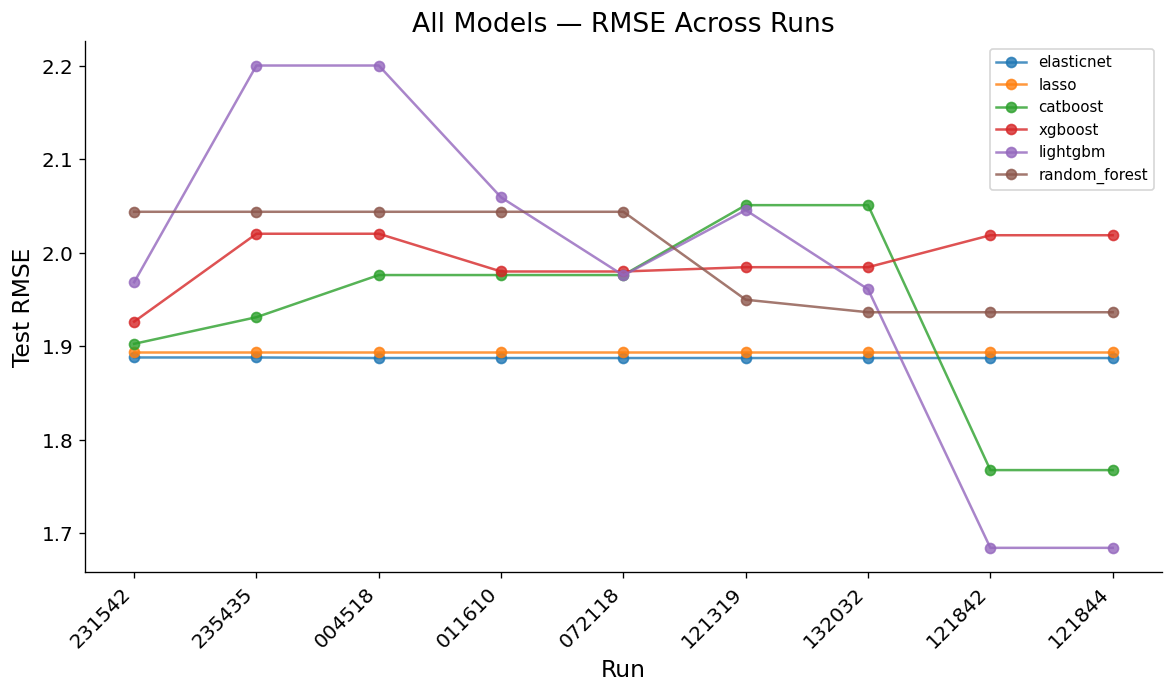

Saved → /Users/zhangjiayu/PythonProject/weather-forecast/outputs/figures/rmse_history.png


In [12]:
history = pd.read_csv(RUN_HISTORY_PATH)
n_runs = history['run_id'].nunique()
print(f"Total runs in history: {n_runs}\n")

# ── 每次 run 的最佳模型 ──
best_per_run = history.loc[history.groupby('run_id')['test_rmse'].idxmin()]
best_per_run = best_per_run[[
    'run_id', 'timestamp', 'model', 'cv_rmse',
    'test_rmse', 'test_r2', 'n_features', 'notes',
]].sort_values('test_rmse')

print("Best model per run (sorted by Test RMSE):")
display(best_per_run.reset_index(drop=True))

global_best = best_per_run.iloc[0]
print(f"\n★ Historical best: run [{global_best['run_id']}] "
      f"model={global_best['model']}, "
      f"Test RMSE={global_best['test_rmse']}")

# ── 多次运行时画趋势图 ──
if n_runs > 1:
    fig, ax = plt.subplots(figsize=(10, 6))

    for model_name in history['model'].unique():
        md = history[history['model'] == model_name].sort_values('run_id')
        ax.plot(range(len(md)), md['test_rmse'].values,
                'o-', label=model_name, markersize=6, alpha=0.8)
    ax.set_xticks(range(n_runs))
    ax.set_xticklabels([rid[-6:] for rid in history['run_id'].unique()],
                       rotation=45, ha='right')
    ax.set_xlabel('Run')
    ax.set_ylabel('Test RMSE')
    ax.set_title('All Models — RMSE Across Runs')
    ax.legend(fontsize=9, loc='upper right')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'rmse_history.png', bbox_inches='tight', dpi=150)
    plt.show()
    print(f"Saved → {FIG_DIR / 'rmse_history.png'}")
else:
    print("\nOnly 1 run so far. Re-run with different params to see comparison charts.")

## 8. 当前 Run 详细参数记录

展示本次运行中所有模型的调优参数，方便回溯。

In [13]:
print(f"Run ID: {run_id}")
print(f"Notes:  {RUN_NOTES or '(none)'}")
print(f"Features: {len(selected_features)}")
print(f"Top {TOP_K}: {top3_names}\n")

param_rows = []
for name in all_results.index:
    info = tuning_info.get(name, {})
    param_rows.append({
        'Model': name,
        'CV RMSE': info.get('cv_rmse', '-'),
        'Test RMSE': all_results.loc[name, 'Test RMSE'],
        'Test R²': all_results.loc[name, 'Test R²'],
        'Top3': '★' if name in top3_names else '',
        'Best Params': json.dumps(info.get('best_params', {}), indent=None),
    })
display(pd.DataFrame(param_rows).set_index('Model'))

Run ID: 20260322_121844
Notes:  (none)
Features: 25
Top 3: ['lightgbm', 'catboost', 'elasticnet']



,CV RMSE,Test RMSE,Test R²,Top3,Best Params
Model,,,,,
lightgbm,2.1917,1.6842,0.9298,★,"{""model__num_leaves"": 23, ""model__n_estimators..."
catboost,2.2226,1.7674,0.9227,★,"{""model__learning_rate"": 0.03, ""model__l2_leaf..."
elasticnet,1.9122,1.8873,0.9118,★,"{""model__alpha"": 0.01, ""model__l1_ratio"": 0.8}"
lasso,1.8875,1.8935,0.9113,,"{""model__alpha"": 0.01}"
random_forest,2.4838,1.9363,0.9072,,"{""model__n_estimators"": 100, ""model__min_sampl..."
xgboost,2.2366,2.0187,0.8991,,"{""model__n_estimators"": 500, ""model__max_depth..."


## 已迁移说明

从这里开始的历史 ensemble 实验已拆分到 `notebooks/04_ensemble.ipynb`。

建议新的使用方式：
- 先运行本 notebook，完成单模型调参、测试集评估与 `run_history.csv` 记录
- 再运行 `notebooks/04_ensemble.ipynb`，从多次 run 历史中挑选每个模型的最佳参数并做一次统一 ensemble

下面只保留迁移说明，不再执行旧版 ensemble 逻辑。

## 9. 已迁移到 `04_ensemble.ipynb`

历史 ensemble 逻辑已迁移到 `notebooks/04_ensemble.ipynb`。

本 notebook 现在只负责：
- 单模型调参
- 测试集评估
- 保存模型与 `run_history.csv`

如需从多次 run 中挑选最佳线性模型与最佳树模型并做一次统一 ensemble，请运行 `notebooks/04_ensemble.ipynb`。

In [ ]:
# Historical ensemble logic moved to `notebooks/04_ensemble.ipynb`.
# This notebook now stops at single-model training, evaluation, and run-history logging.

## 10. 已迁移到 `04_ensemble.ipynb`

集成对比图、最终 RMSE 记录和历史 ensemble 结果保存，已经单独放到 `notebooks/04_ensemble.ipynb`。

In [ ]:
# Historical ensemble validation moved to `notebooks/04_ensemble.ipynb`.